
# Step 1 : Import Libraries




In [40]:
# Uncomment บรรทัดด้านล่างถ้ายังไม่ได้ติดตั้ง
# !pip install pandas numpy scikit-learn matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn — ML models & metrics
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# ── Style ─────────────────────────────────────────────────────
plt.style.use('dark_background')
COLORS = {
    'AAPL' : '#76b900',   # เขียว AAPL
    'MSFT' : '#ff9900',   # ส้ม MSFT
    'AMZN': '#4285f4',   # น้ำเงิน AMZN
    'JPM' : '#aaaaaa',   # เทา JPM
    'KO' : '#00bcf2',   # ฟ้า KO
}
TICKERS = ['AAPL','MSFT','AMZN','JPM','KO']

print("✅ Import สำเร็จทุก library!")


✅ Import สำเร็จทุก library!


# Step 2 : Load Dataset

In [57]:
# ── โหลดไฟล์ — เปลี่ยน path ให้ตรงกับของคุณ ───────────────────
df = pd.read_csv('/content/StockPriceDataset.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print(f" Shape      : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f" Date range : {df['Date'].min().date()}  →  {df['Date'].max().date()}")
print(f" Columns    : {list(df.columns)}")
df.head(3)


 Shape      : 25,160 rows × 8 columns
 Date range : 2014-01-02  →  2023-12-29
 Columns    : ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Ticker']


,Date,Open,High,Low,Close,Adj Close,Volume,Ticker
0,2014-01-02,19.845715,19.893929,19.715,19.754642,17.273226,234684800,AAPL
1,2014-01-02,81.330002,81.360001,80.320,80.540001,59.643745,6981700,PG
2,2014-01-02,19.940001,19.968000,19.701,19.898500,19.898500,42756000,AMZN


# Step 3 : Exploratory Data Analysis (EDA)





In [42]:
# ── ตรวจสอบ Missing Values ───────────────────────────────────
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.any() else "✅ ไม่มี missing values!")

# ── สถิติพื้นฐาน (ราคาปิดทุกตัว) ─────────────────────────────
# เนื่องจาก df อยู่ในรูปแบบ long format (ทุก Ticker อยู่ใน df เดียวกัน)
# เราจะใช้ groupby เพื่อดูสถิติของราคาปิดของแต่ละ Ticker
close_stats = df.groupby('Ticker')['Close'].describe().round(2)
print("\nสถิติพื้นฐานของราคาปิดแต่ละหุ้น:")
print(close_stats)

Missing values per column:
✅ ไม่มี missing values!

สถิติพื้นฐานของราคาปิดแต่ละหุ้น:
         count    mean     std     min     25%     50%     75%     max
Ticker                                                                
AAPL    2516.0   77.92   56.23   17.85   29.80   48.11  134.56  198.11
AMZN    2516.0   84.41   51.40   14.35   36.37   86.81  127.12  186.57
CAT     2516.0  145.26   57.66   57.91   96.26  134.38  194.84  298.12
GS      2516.0  244.68   72.55  134.97  189.14  222.91  313.88  423.85
JNJ     2516.0  135.57   25.27   86.62  113.70  135.64  158.50  186.01
JPM     2516.0  103.81   33.50   53.07   67.17  105.59  131.45  171.78
KO      2516.0   49.17    7.52   37.10   42.69   46.45   55.02   66.21
MSFT    2516.0  149.86  101.64   34.98   55.69  109.93  243.01  382.70
PG      2516.0  109.08   28.46   68.06   83.05   93.50  138.01  164.21
XOM     2516.0   80.42   18.65   31.45   71.74   82.05   91.51  120.20


# Step 4 : Feature Engineering

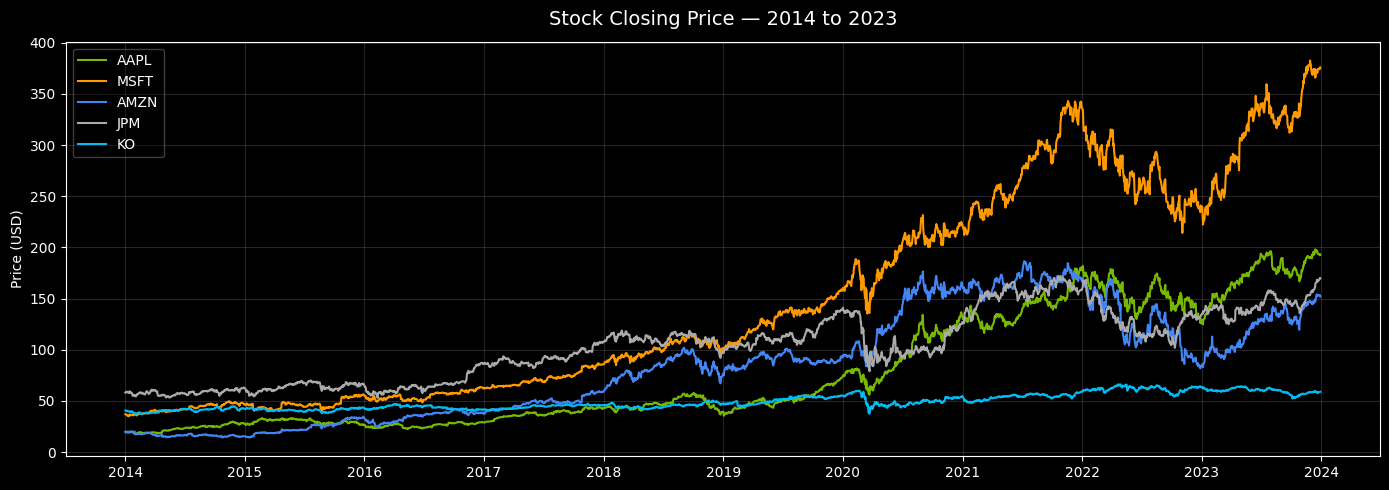

 สังเกตการเคลื่อนไหวของราคาหุ้นที่เลือกไว้


In [58]:
# ── Plot: ราคาหุ้นทุกตัว 15 ปี ──────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

for ticker in TICKERS:
    # Filter the DataFrame for the current ticker and plot its 'Close' price
    ticker_df = df[df['Ticker'] == ticker]
    ax.plot(ticker_df['Date'], ticker_df['Close'],
            label=ticker, color=COLORS[ticker], linewidth=1.5)

ax.set_title('Stock Closing Price — 2014 to 2023', fontsize=14, pad=12)
ax.set_ylabel('Price (USD)')
ax.legend(loc='upper left', framealpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(alpha=0.15)
plt.tight_layout()
plt.show()

print(" สังเกตการเคลื่อนไหวของราคาหุ้นที่เลือกไว้")


In [44]:
def create_features(df, ticker):
    """
    สร้าง feature matrix สำหรับหุ้น 1 ตัว

    Parameters
    ----------
    df     : DataFrame ที่โหลดจาก CSV (ซึ่งมีข้อมูลทุกหุ้นในรูปแบบ long format)
    ticker : ชื่อหุ้น เช่น 'MSFT'

    Returns
    -------
    DataFrame พร้อม features และ target column สำหรับหุ้นตัวนั้น
    """
    # 1. กรองข้อมูลเฉพาะหุ้นตัวนี้
    ticker_data = df[df['Ticker'] == ticker].copy()

    # 2. เลือกคอลัมน์ที่ต้องการ (ซึ่งตอนนี้มีชื่อมาตรฐานแล้วเพราะถูกกรองมาแล้ว)
    data = ticker_data[['Date', 'Close', 'High', 'Low', 'Open', 'Volume']].copy()

    # ── Features พื้นฐาน ────────────────────────────────────────
    data['Returns']     = data['Close'].pct_change()
    data['Price_Range'] = data['High'] - data['Low']

    # ── Moving Averages ──────────────────────────────────────────
    data['MA5']  = data['Close'].rolling(5).mean()
    data['MA20'] = data['Close'].rolling(20).mean()
    data['MA50'] = data['Close'].rolling(50).mean()

    # ── Volatility (20-day rolling std of returns) ───────────────
    data['Volatility'] = data['Returns'].rolling(20).std()

    # ── RSI — Relative Strength Index (14-day) ───────────────────
    gain     = data['Returns'].clip(lower=0)
    loss     = (-data['Returns']).clip(lower=0)
    avg_gain = gain.rolling(14).mean()
    avg_loss = loss.rolling(14).mean()
    rs       = avg_gain / (avg_loss + 1e-10)   # +1e-10 ป้องกัน divide by zero
    data['RSI'] = 100 - (100 / (1 + rs))

    # ── Volume Ratio ─────────────────────────────────────────────
    data['Volume_MA']    = data['Volume'].rolling(20).mean()
    data['Volume_Ratio'] = data['Volume'] / (data['Volume_MA'] + 1e-10)

    # ── Target: ราคาปิดวันถัดไป ──────────────────────────────────
    data['Target_Price'] = data['Close'].shift(-1)

    # ลบแถวที่มี NaN (จาก rolling window และ shift)
    return data.dropna().reset_index(drop=True)


# ── ทดสอบกับ MSFT ────────────────────────────────────────────
sample = create_features(df, 'MSFT')
print(f"MSFT — หลัง feature engineering: {len(sample):,} rows")
print(f"Features: {[c for c in sample.columns if c not in ['Date','Target_Price']]}")
sample[['Date','Close','MA5','MA20','RSI','Volatility','Target_Price']].head(5)

MSFT — หลัง feature engineering: 2,466 rows
Features: ['Close', 'High', 'Low', 'Open', 'Volume', 'Returns', 'Price_Range', 'MA5', 'MA20', 'MA50', 'Volatility', 'RSI', 'Volume_MA', 'Volume_Ratio']


,Date,Close,MA5,MA20,RSI,Volatility,Target_Price
0,2014-03-14,37.700001,37.940,37.8600,50.381483,0.007990,38.049999
1,2014-03-17,38.049999,37.986,37.8815,56.487201,0.008247,39.549999
2,2014-03-18,39.549999,38.292,37.9880,68.971181,0.011842,39.270000
3,2014-03-19,39.270000,38.492,38.0760,63.278734,0.012048,40.330002
4,2014-03-20,40.330002,38.980,38.2050,66.798210,0.013233,40.160000


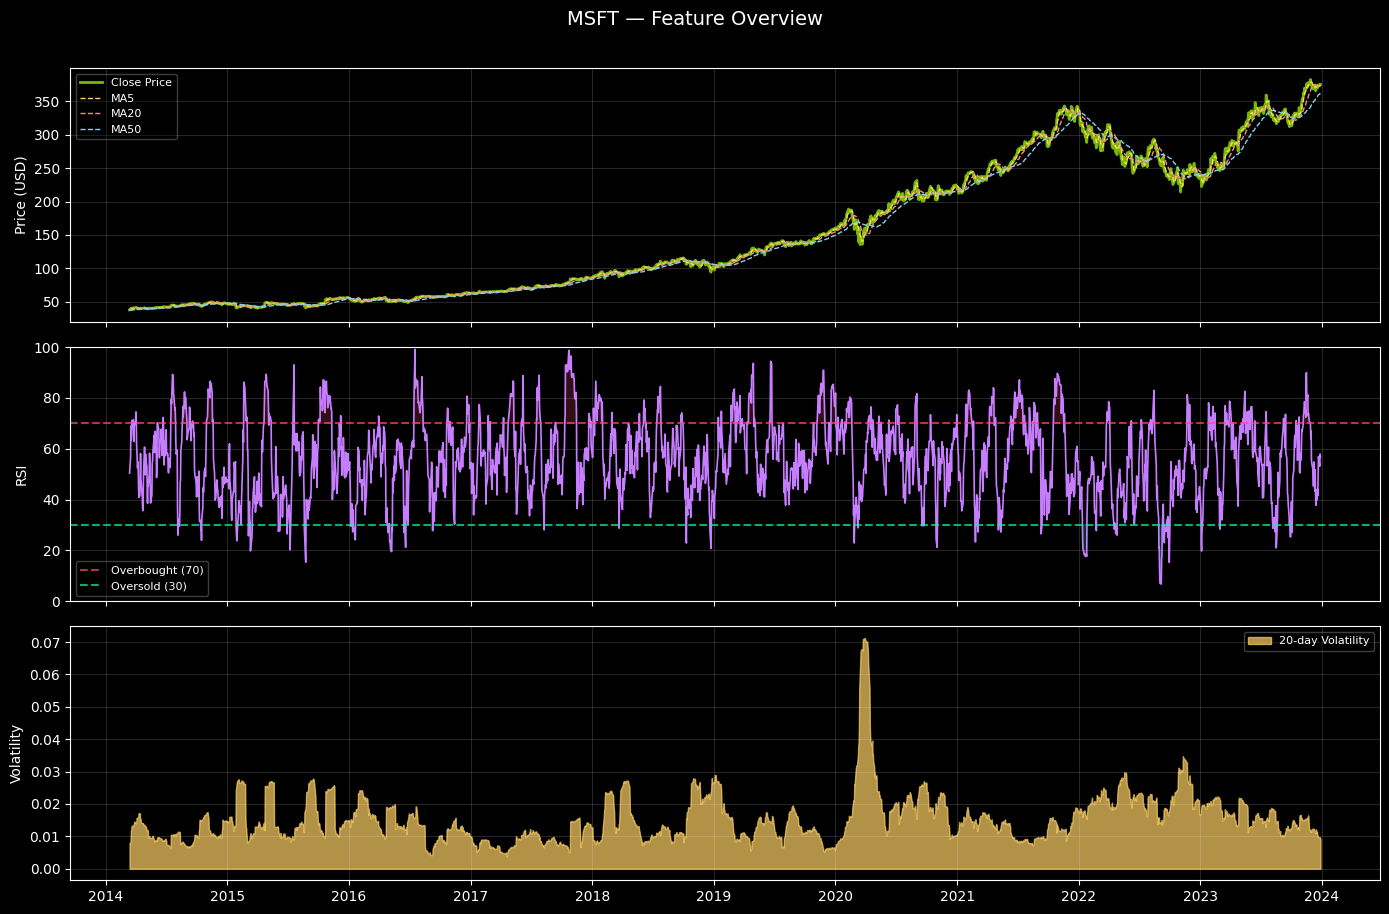

In [45]:
# ── Visualize Features บน MSFT ───────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
fig.suptitle('MSFT — Feature Overview', fontsize=14, y=1.01)

# 1. ราคา + Moving Averages
ax = axes[0]
ax.plot(sample['Date'], sample['Close'], color='#76b900', lw=2,   label='Close Price')
ax.plot(sample['Date'], sample['MA5'],   color='#ffd166', lw=1,   ls='--', label='MA5')
ax.plot(sample['Date'], sample['MA20'],  color='#ef8c8c', lw=1,   ls='--', label='MA20')
ax.plot(sample['Date'], sample['MA50'],  color='#88ccee', lw=1,   ls='--', label='MA50')
ax.set_ylabel('Price (USD)')
ax.legend(loc='upper left', fontsize=8, framealpha=0.3)
ax.grid(alpha=0.15)

# 2. RSI
ax = axes[1]
ax.plot(sample['Date'], sample['RSI'], color='#c77dff', lw=1.2)
ax.axhline(70, color='#ff4d6a', ls='--', alpha=0.7, label='Overbought (70)')
ax.axhline(30, color='#00ff9d', ls='--', alpha=0.7, label='Oversold (30)')
ax.fill_between(sample['Date'], sample['RSI'], 70,
                where=(sample['RSI'] >= 70), alpha=0.2, color='#ff4d6a')
ax.fill_between(sample['Date'], sample['RSI'], 30,
                where=(sample['RSI'] <= 30), alpha=0.2, color='#00ff9d')
ax.set_ylabel('RSI')
ax.set_ylim(0, 100)
ax.legend(fontsize=8, framealpha=0.3)
ax.grid(alpha=0.15)

# 3. Volatility
ax = axes[2]
ax.fill_between(sample['Date'], sample['Volatility'],
                alpha=0.7, color='#ffd166', label='20-day Volatility')
ax.set_ylabel('Volatility')
ax.legend(fontsize=8, framealpha=0.3)
ax.grid(alpha=0.15)

plt.tight_layout()
plt.show()


In [59]:
FEATURE_COLS = [
    'Close', 'Open', 'High', 'Low', 'Volume',
    'Returns', 'MA5', 'MA20', 'MA50',
    'Volatility', 'RSI', 'Price_Range', 'Volume_Ratio'
]


def split_and_scale(data, feature_cols, split_ratio=0.8):
    """
    แบ่ง train/test แบบ time-based แล้ว StandardScale

    Returns
    -------
    X_train_s, X_test_s  : scaled features
    y_train, y_test      : target prices
    dates_test           : index วันที่ของ test set (สำหรับ plot)
    """
    n   = len(data)
    idx = int(n * split_ratio)

    X      = data[feature_cols]
    y      = data['Target_Price']

    X_train, X_test = X[:idx], X[idx:]
    y_train, y_test = y[:idx], y[idx:]
    dates_test      = data['Date'].iloc[idx:].reset_index(drop=True)

    # Scale — fit บน train เท่านั้น!
    scaler    = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)   # ใช้ mean/std จาก train

    print(f"   Train: {len(X_train):,} rows  "
          f"({data['Date'].iloc[0].date()} → {data['Date'].iloc[idx-1].date()})")
    print(f"   Test : {len(X_test):,} rows  "
          f"({data['Date'].iloc[idx].date()} → {data['Date'].iloc[-1].date()})")

    return X_train_s, X_test_s, y_train, y_test, dates_test


# ทดสอบกับ MSFT
print("MSFT — Split:")
msft_data = create_features(df, 'MSFT')
X_tr, X_te, y_tr, y_te, dates_te = split_and_scale(msft_data, FEATURE_COLS)

print(f"\n  X_train shape : {X_tr.shape}")
print(f"  X_test shape  : {X_te.shape}")
print(f"  y_train range : ${y_tr.min():.2f} – ${y_tr.max():.2f}")
print(f"  y_test range  : ${y_te.min():.2f} – ${y_te.max():.2f}")


MSFT — Split:
   Train: 1,972 rows  (2014-03-14 → 2022-01-10)
   Test : 494 rows  (2022-01-11 → 2023-12-28)

  X_train shape : (1972, 13)
  X_test shape  : (494, 13)
  y_train range : $38.05 – $343.11
  y_test range  : $214.25 – $382.70


# Step 5 : Feature Correlation Heatmap

MSFT — หลัง feature engineering: 2,466 rows


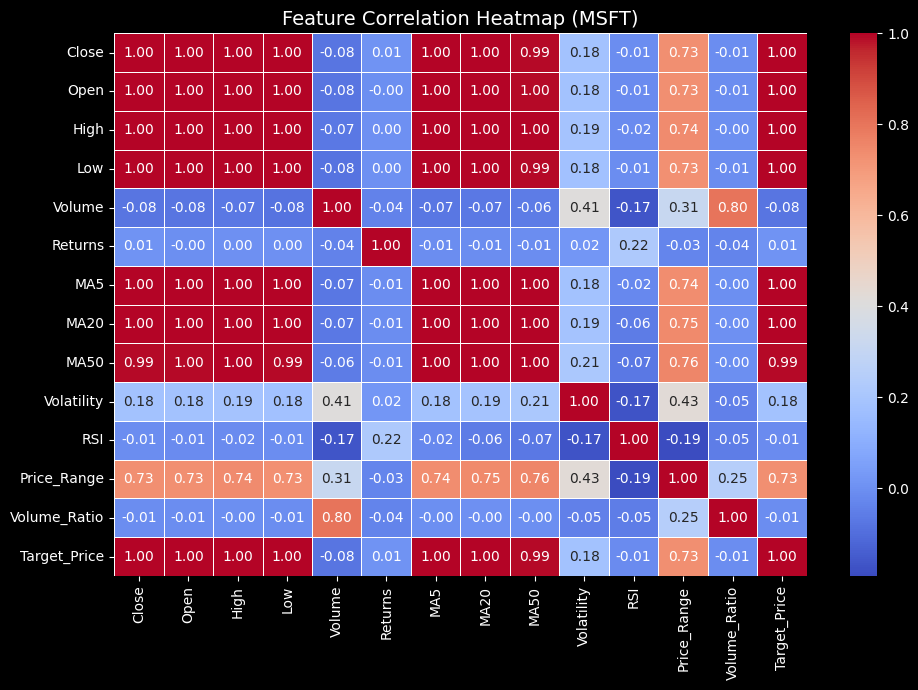

In [56]:
sample = create_features(df, 'MSFT')

print(f"MSFT — หลัง feature engineering: {len(sample):,} rows")

# -----------------------------
# Heatmap (EDA)
# -----------------------------
plt.figure(figsize=(10,7))

corr = sample[FEATURE_COLS + ['Target_Price']].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap (MSFT)", fontsize=14)
plt.tight_layout()
plt.show()

# Step 6 : Train/Test Split & Scaling

In [60]:
def train_rf_regressor(X_train, X_test, y_train, y_test):
    """
    Train Random Forest Regressor และ return ผลลัพธ์

    Returns
    -------
    model   : trained model
    y_pred  : predictions บน test set
    rmse    : Root Mean Squared Error (หน่วยเดียวกับราคา $)
    r2      : R-squared score
    """
    model = RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )

    print("   Training Random Forest... ", end='')
    model.fit(X_train, y_train)
    print("done!")

    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    return model, y_pred, rmse, r2


# Train กับ MSFT
print("MSFT — Training:")
rf_model, y_pred, rmse, r2 = train_rf_regressor(X_tr, X_te, y_tr, y_te)

print(f"\n   RMSE  = ${rmse:.4f}")
print(f"   R²    = {r2:.4f}")
print()

# อธิบาย metrics
if r2 >= 0.8:
    print(f"   R²={r2:.3f} — โมเดล fit ได้ดีมาก!")
elif r2 >= 0.5:
    print(f"    R²={r2:.3f} — โมเดล fit ได้ปานกลาง")
elif r2 >= 0:
    print(f"    R²={r2:.3f} — โมเดล fit ได้น้อย")
else:
    print(f"   R²={r2:.3f} — โมเดลแย่กว่า baseline (mean prediction)")
    print(f"      → หุ้นผันผวนมากเกินไปในช่วง test set")


MSFT — Training:
   Training Random Forest... done!

   RMSE  = $13.2766
   R²    = 0.8953

   R²=0.895 — โมเดล fit ได้ดีมาก!


# Step 7 : Model Evaluation

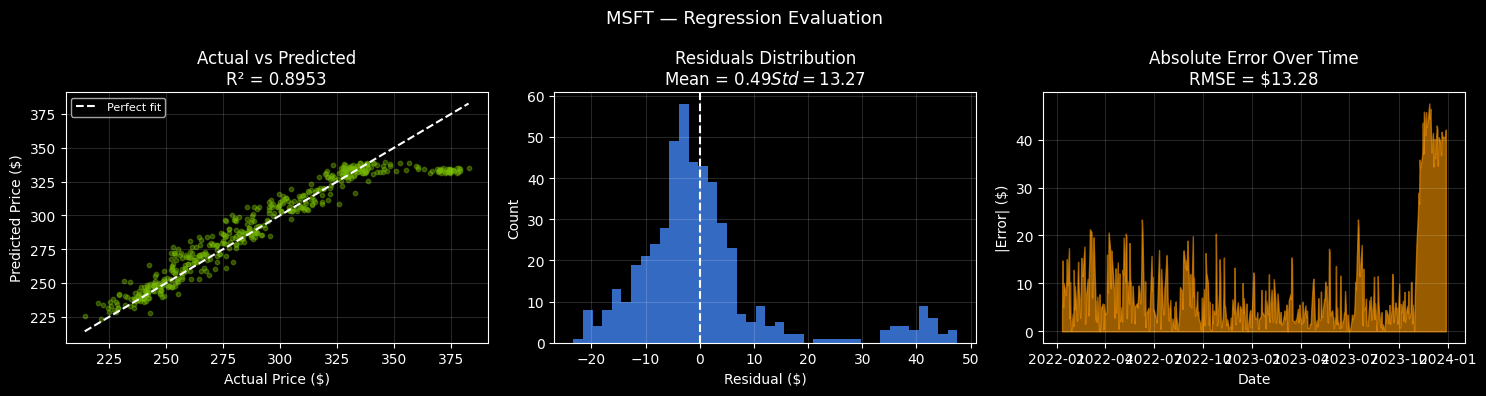

In [49]:
# ── Residual Analysis ────────────────────────────────────────
residuals = np.array(y_te) - y_pred

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('MSFT — Regression Evaluation', fontsize=13)

# 1. Actual vs Predicted scatter
ax = axes[0]
ax.scatter(y_te, y_pred, alpha=0.4, color='#76b900', s=10)
mn, mx = min(y_te.min(), y_pred.min()), max(y_te.max(), y_pred.max())
ax.plot([mn, mx], [mn, mx], color='white', lw=1.5, ls='--', label='Perfect fit')
ax.set_xlabel('Actual Price ($)')
ax.set_ylabel('Predicted Price ($)')
ax.set_title(f'Actual vs Predicted\nR² = {r2:.4f}')
ax.legend(fontsize=8)
ax.grid(alpha=0.15)

# 2. Residuals distribution
ax = axes[1]
ax.hist(residuals, bins=40, color='#4285f4', edgecolor='none', alpha=0.8)
ax.axvline(0, color='white', lw=1.5, ls='--')
ax.set_xlabel('Residual ($)')
ax.set_ylabel('Count')
ax.set_title(f'Residuals Distribution\nMean = ${residuals.mean():.2f}  Std = ${residuals.std():.2f}')
ax.grid(alpha=0.15)

# 3. Absolute error over time
ax = axes[2]
ax.fill_between(dates_te, np.abs(residuals), alpha=0.6, color='#ff9900')
ax.set_xlabel('Date')
ax.set_ylabel('|Error| ($)')
ax.set_title(f'Absolute Error Over Time\nRMSE = ${rmse:.2f}')
ax.grid(alpha=0.15)

plt.tight_layout()
plt.show()


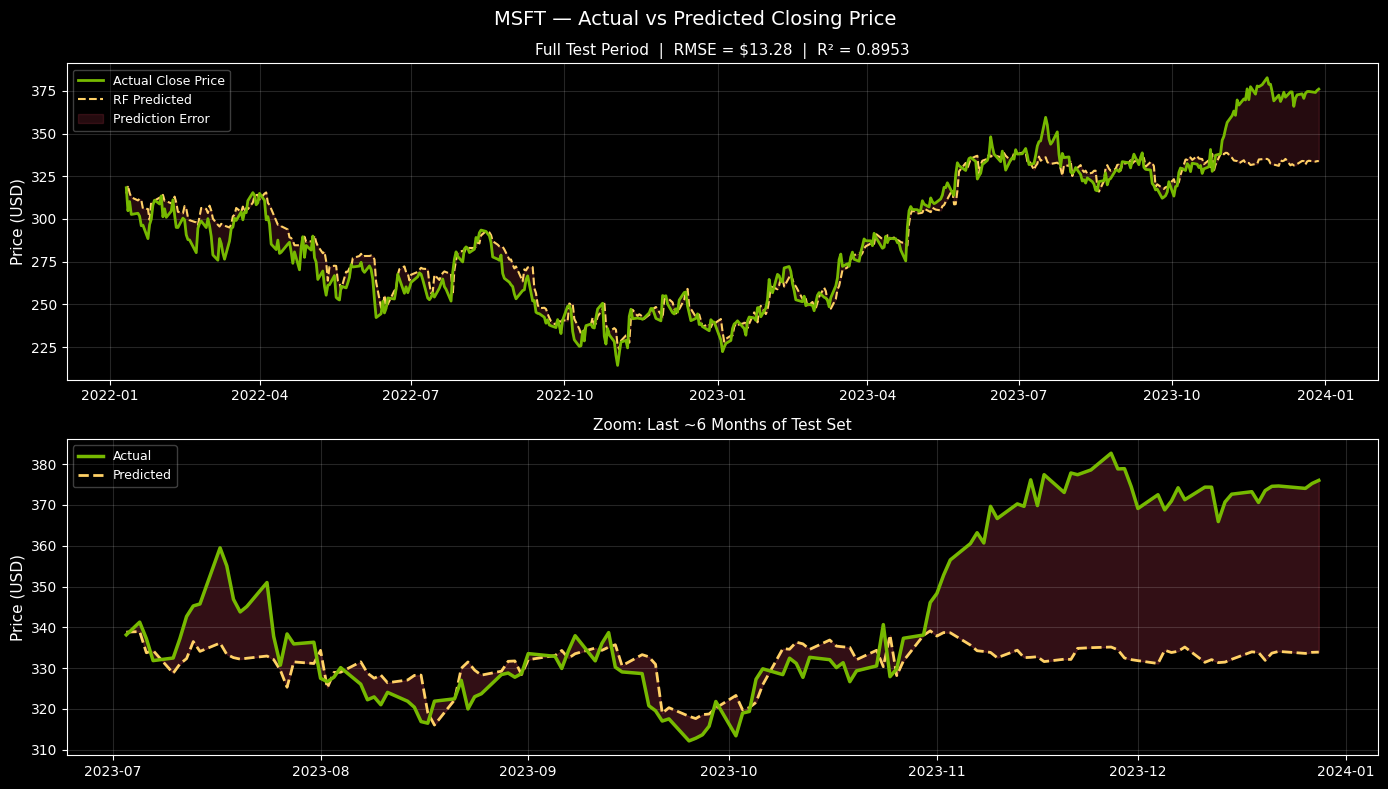

In [50]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('MSFT — Actual vs Predicted Closing Price', fontsize=14)

# ── Plot 1: ภาพรวม test period ──────────────────────────────
ax = axes[0]
ax.plot(dates_te, np.array(y_te),  color='#76b900', lw=2,   label='Actual Close Price',  zorder=3)
ax.plot(dates_te, y_pred,          color='#ffd166', lw=1.5, label='RF Predicted',  ls='--', zorder=2)
ax.fill_between(dates_te,
                np.array(y_te), y_pred,
                alpha=0.15, color='#ff4d6a', label='Prediction Error')
ax.set_ylabel('Price (USD)', fontsize=11)
ax.set_title(f'Full Test Period  |  RMSE = ${rmse:.2f}  |  R² = {r2:.4f}', fontsize=11)
ax.legend(fontsize=9, framealpha=0.3)
ax.grid(alpha=0.15)

# ── Plot 2: Zoom ─────────────────────────────────────────────
# แสดง 6 เดือนสุดท้าย
last_n = 125
ax = axes[1]
ax.plot(dates_te.iloc[-last_n:], np.array(y_te)[-last_n:],
        color='#76b900', lw=2.5, label='Actual', zorder=3)
ax.plot(dates_te.iloc[-last_n:], y_pred[-last_n:],
        color='#ffd166', lw=2, label='Predicted', ls='--', zorder=2)
ax.fill_between(dates_te.iloc[-last_n:],
                np.array(y_te)[-last_n:], y_pred[-last_n:],
                alpha=0.2, color='#ff4d6a')
ax.set_ylabel('Price (USD)', fontsize=11)
ax.set_title('Zoom: Last ~6 Months of Test Set', fontsize=11)
ax.legend(fontsize=9, framealpha=0.3)
ax.grid(alpha=0.15)

plt.tight_layout()
plt.show()


# Step 8 : Feature Importance (MSFT)

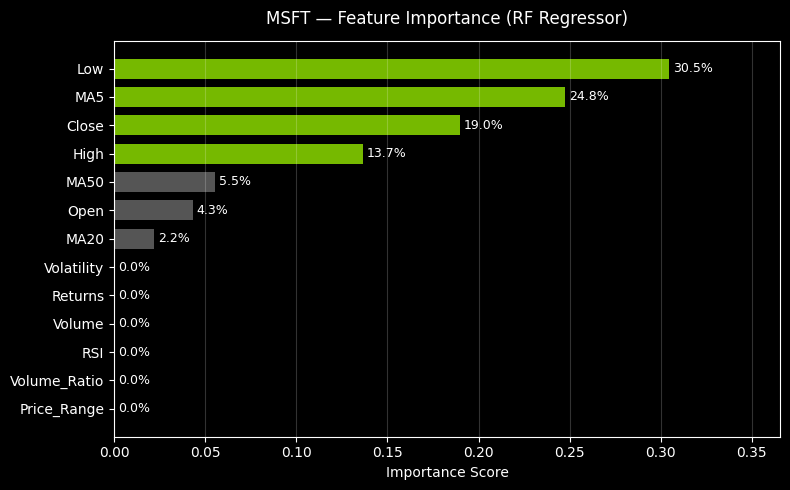


 Top 3 Most Important Features:
  Low              30.5%
  MA5              24.8%
  Close            19.0%


In [61]:
importances = rf_model.feature_importances_
feat_df = pd.DataFrame({
    'Feature'   : FEATURE_COLS,
    'Importance': importances
}).sort_values('Importance', ascending=True)

# ── Horizontal bar chart ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

colors_bar = ['#76b900' if imp > 0.1 else '#555' for imp in feat_df['Importance']]
bars = ax.barh(feat_df['Feature'], feat_df['Importance'],
               color=colors_bar, edgecolor='none', height=0.7)

# แสดงค่า % บนแต่ละ bar
for bar, imp in zip(bars, feat_df['Importance']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{imp*100:.1f}%', va='center', fontsize=9, color='white')

ax.set_title('MSFT — Feature Importance (RF Regressor)', fontsize=12, pad=12)
ax.set_xlabel('Importance Score')
ax.set_xlim(0, feat_df['Importance'].max() * 1.2)
ax.grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.show()

# Top 3 features
print("\n Top 3 Most Important Features:")
for i, row in feat_df.tail(3).iloc[::-1].iterrows():
    print(f"  {row['Feature']:15s}  {row['Importance']*100:.1f}%")


# Step 9 : Train & Evaluate All Tickers

In [62]:
results = []

print(" Training models for all tickers...\n")

for ticker in TICKERS:
    # 1. Feature engineering
    data = create_features(df, ticker)

    # 2. Split & scale
    X_tr, X_te, y_tr, y_te, dates_te = split_and_scale(data, FEATURE_COLS)

    # 3. Train & evaluate
    model, y_pred, rmse, r2 = train_rf_regressor(X_tr, X_te, y_tr, y_te)

    # 4. Feature importance (top feature)
    top_idx  = np.argmax(model.feature_importances_)
    top_feat = FEATURE_COLS[top_idx]
    top_pct  = model.feature_importances_[top_idx] * 100

    results.append({
        'Ticker'       : ticker,
        'Current Price': f"${data['Close'].iloc[-1]:.2f}",
        'RMSE ($)'     : round(rmse, 2),
        'R²'           : round(r2, 4),
        'Top Feature'  : f"{top_feat} ({top_pct:.0f}%)"
    })
    print(f"   {ticker:5s} — RMSE=${rmse:.2f}  R²={r2:.4f}  Top feat: {top_feat}")

print("\n" + "="*65)
print(" SUMMARY")
print("="*65)
results_df = pd.DataFrame(results).set_index('Ticker')
results_df


 Training models for all tickers...

   Train: 1,972 rows  (2014-03-14 → 2022-01-10)
   Test : 494 rows  (2022-01-11 → 2023-12-28)
   Training Random Forest... done!
   AAPL  — RMSE=$7.32  R²=0.8301  Top feat: Close
   Train: 1,972 rows  (2014-03-14 → 2022-01-10)
   Test : 494 rows  (2022-01-11 → 2023-12-28)
   Training Random Forest... done!
   MSFT  — RMSE=$13.28  R²=0.8953  Top feat: Low
   Train: 1,972 rows  (2014-03-14 → 2022-01-10)
   Test : 494 rows  (2022-01-11 → 2023-12-28)
   Training Random Forest... done!
   AMZN  — RMSE=$8.45  R²=0.8414  Top feat: Close
   Train: 1,972 rows  (2014-03-14 → 2022-01-10)
   Test : 494 rows  (2022-01-11 → 2023-12-28)
   Training Random Forest... done!
   JPM   — RMSE=$2.50  R²=0.9689  Top feat: Low
   Train: 1,972 rows  (2014-03-14 → 2022-01-10)
   Test : 494 rows  (2022-01-11 → 2023-12-28)
   Training Random Forest... done!
   KO    — RMSE=$2.27  R²=0.2907  Top feat: Close

 SUMMARY


,Current Price,RMSE ($),R²,Top Feature
Ticker,,,,
AAPL,$193.58,7.32,0.8301,Close (32%)
MSFT,$375.28,13.28,0.8953,Low (30%)
AMZN,$153.38,8.45,0.8414,Close (46%)
JPM,$170.30,2.50,0.9689,Low (55%)
KO,$58.75,2.27,0.2907,Close (48%)


# Step 10 : Comparison Visualization

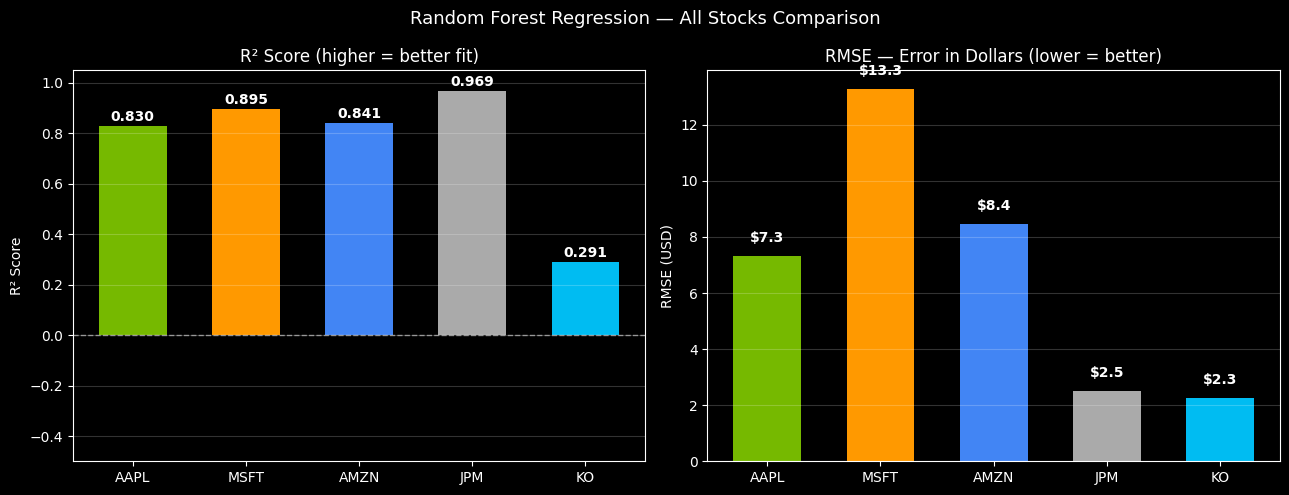

In [53]:
# ── Comparison Chart ──────────────────────────────────────────
r2_vals   = [r['R²']       for r in results]
rmse_vals = [r['RMSE ($)'] for r in results]
tickers   = [r['Ticker']   for r in results]
colors    = [COLORS[t]     for t in tickers]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Random Forest Regression — All Stocks Comparison', fontsize=13)

# R²
ax = axes[0]
bars = ax.bar(tickers, r2_vals, color=colors, edgecolor='none', width=0.6)
ax.axhline(0, color='white', lw=1, ls='--', alpha=0.5)
ax.set_ylabel('R² Score')
ax.set_title('R² Score (higher = better fit)')
ax.set_ylim(min(min(r2_vals)-0.15, -0.5), 1.05)
ax.grid(axis='y', alpha=0.2)
for bar, v in zip(bars, r2_vals):
    ypos = v + 0.02 if v >= 0 else v - 0.05
    ax.text(bar.get_x() + bar.get_width()/2, ypos, f'{v:.3f}',
            ha='center', fontsize=10, fontweight='bold')

# RMSE
ax = axes[1]
bars = ax.bar(tickers, rmse_vals, color=colors, edgecolor='none', width=0.6)
ax.set_ylabel('RMSE (USD)')
ax.set_title('RMSE — Error in Dollars (lower = better)')
ax.grid(axis='y', alpha=0.2)
for bar, v in zip(bars, rmse_vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.5,
            f'${v:.1f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


# Step 11 : Feature Importance (All Tickers)

In [63]:
# ── Feature Importance (ทุกหุ้น) ────────────────────
importance_matrix = {}

for ticker in TICKERS:
    data  = create_features(df, ticker)
    X_tr, X_te, y_tr, y_te, _ = split_and_scale(data, FEATURE_COLS)
    model, _, _, _ = train_rf_regressor(X_tr, X_te, y_tr, y_te)
    importance_matrix[ticker] = model.feature_importances_

imp_df = pd.DataFrame(importance_matrix, index=FEATURE_COLS)

   Train: 1,972 rows  (2014-03-14 → 2022-01-10)
   Test : 494 rows  (2022-01-11 → 2023-12-28)
   Training Random Forest... done!
   Train: 1,972 rows  (2014-03-14 → 2022-01-10)
   Test : 494 rows  (2022-01-11 → 2023-12-28)
   Training Random Forest... done!
   Train: 1,972 rows  (2014-03-14 → 2022-01-10)
   Test : 494 rows  (2022-01-11 → 2023-12-28)
   Training Random Forest... done!
   Train: 1,972 rows  (2014-03-14 → 2022-01-10)
   Test : 494 rows  (2022-01-11 → 2023-12-28)
   Training Random Forest... done!
   Train: 1,972 rows  (2014-03-14 → 2022-01-10)
   Test : 494 rows  (2022-01-11 → 2023-12-28)
   Training Random Forest... done!
